# required package

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2.2) Forecasting the historical mean

## 2.2.1) Setup for baseline implemetations

In [2]:
df = pd.read_csv("data/jj.csv")

In [3]:
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [4]:
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


In [5]:
train = df[:-4]
test = df[-4:]

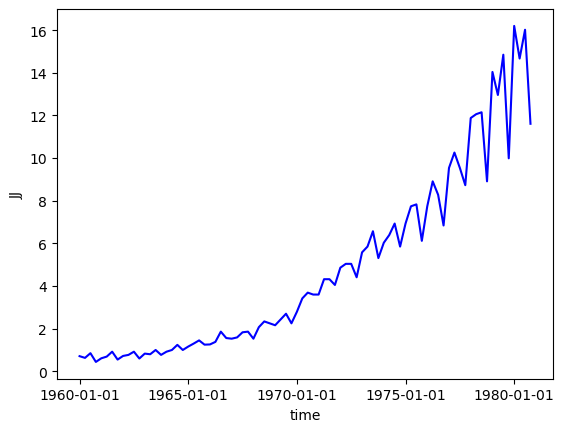

In [6]:
fig, ax = plt.subplots()
ax.plot(df.date, df.data, 'b-')
ax.set_xticks(df.date[np.arange(0, 83, 20)])
ax.set_xlabel('time')
ax.set_ylabel('JJ')
plt.show()

## 2.2.2) Implementing the historical mean baseline

In [7]:
historical_mean = train.data.mean()

In [8]:
historical_mean

4.308499987499999

In [9]:
test.loc[:, 'pred_mean'] = historical_mean

/tmp/ipykernel_9025/3433673524.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_mean'] = historical_mean


In [10]:
test

,date,data,pred_mean
80,1980-01-01,16.20,4.3085
81,1980-04-01,14.67,4.3085
82,1980-07-02,16.02,4.3085
83,1980-10-01,11.61,4.3085


In [11]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 80 to 83
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       4 non-null      object 
 1   data       4 non-null      float64
 2   pred_mean  4 non-null      float64
dtypes: float64(2), object(1)
memory usage: 228.0+ bytes


In [12]:
mape_hist_mean = test.apply(lambda x: 100. * np.abs((x['data'] - x['pred_mean']) / x['data']), axis=1).mean()

In [13]:
mape_hist_mean

70.00752579965119

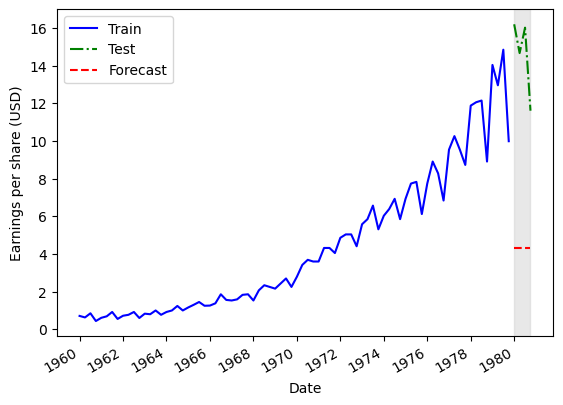

In [14]:
fig, ax = plt.subplots()
ax.plot(train['date'], train['data'], 'b-', label='Train')
ax.plot(test['date'], test['data'], 'g-.', label='Test')
ax.plot(test['date'], test['pred_mean'], 'r--', label='Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='lightgray', alpha=0.5)
ax.legend()
plt.xticks(np.arange(0, 85, 8), np.arange(1960, 1981, 2))
fig.autofmt_xdate()
plt.show()

# 2.3) Forecasting last year's mean

In [15]:
last_year_mean = np.mean(train.iloc[-4:, 1])
last_year_mean

12.96

In [16]:
test.loc[:, 'pred__last_year_mean'] = last_year_mean

/tmp/ipykernel_9025/712055117.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred__last_year_mean'] = last_year_mean


In [17]:
mape = lambda y, p: 100 * np.mean(np.abs( (y - p) / y ))

In [18]:
mape(test['data'], test['pred__last_year_mean'])

15.5963680725103

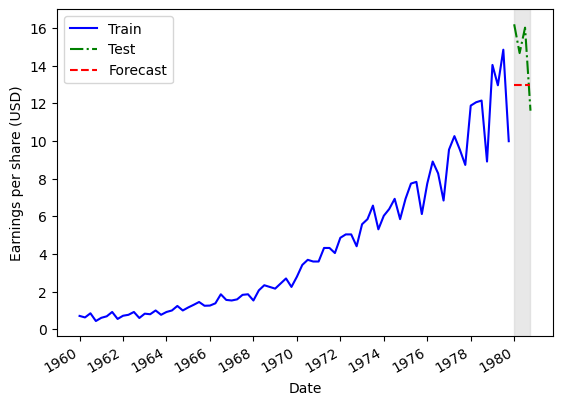

In [19]:
fig, ax = plt.subplots()
ax.plot(train['date'], train['data'], 'b-', label='Train')
ax.plot(test['date'], test['data'], 'g-.', label='Test')
ax.plot(test['date'], test['pred__last_year_mean'], 'r--', label='Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='lightgray', alpha=0.5)
ax.legend()
plt.xticks(np.arange(0, 85, 8), np.arange(1960, 1981, 2))
fig.autofmt_xdate()
plt.show()

# 2.4) Predicting using the last known value

In [20]:
last = train.data.iloc[-1]
last

9.99

In [21]:
test.loc[:, "pred_last"] = last

/tmp/ipykernel_9025/1527279460.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, "pred_last"] = last


In [22]:
mape(test.data, test.pred_last)

30.457277908606535

In [23]:
test.columns

Index(['date', 'data', 'pred_mean', 'pred__last_year_mean', 'pred_last'], dtype='object')

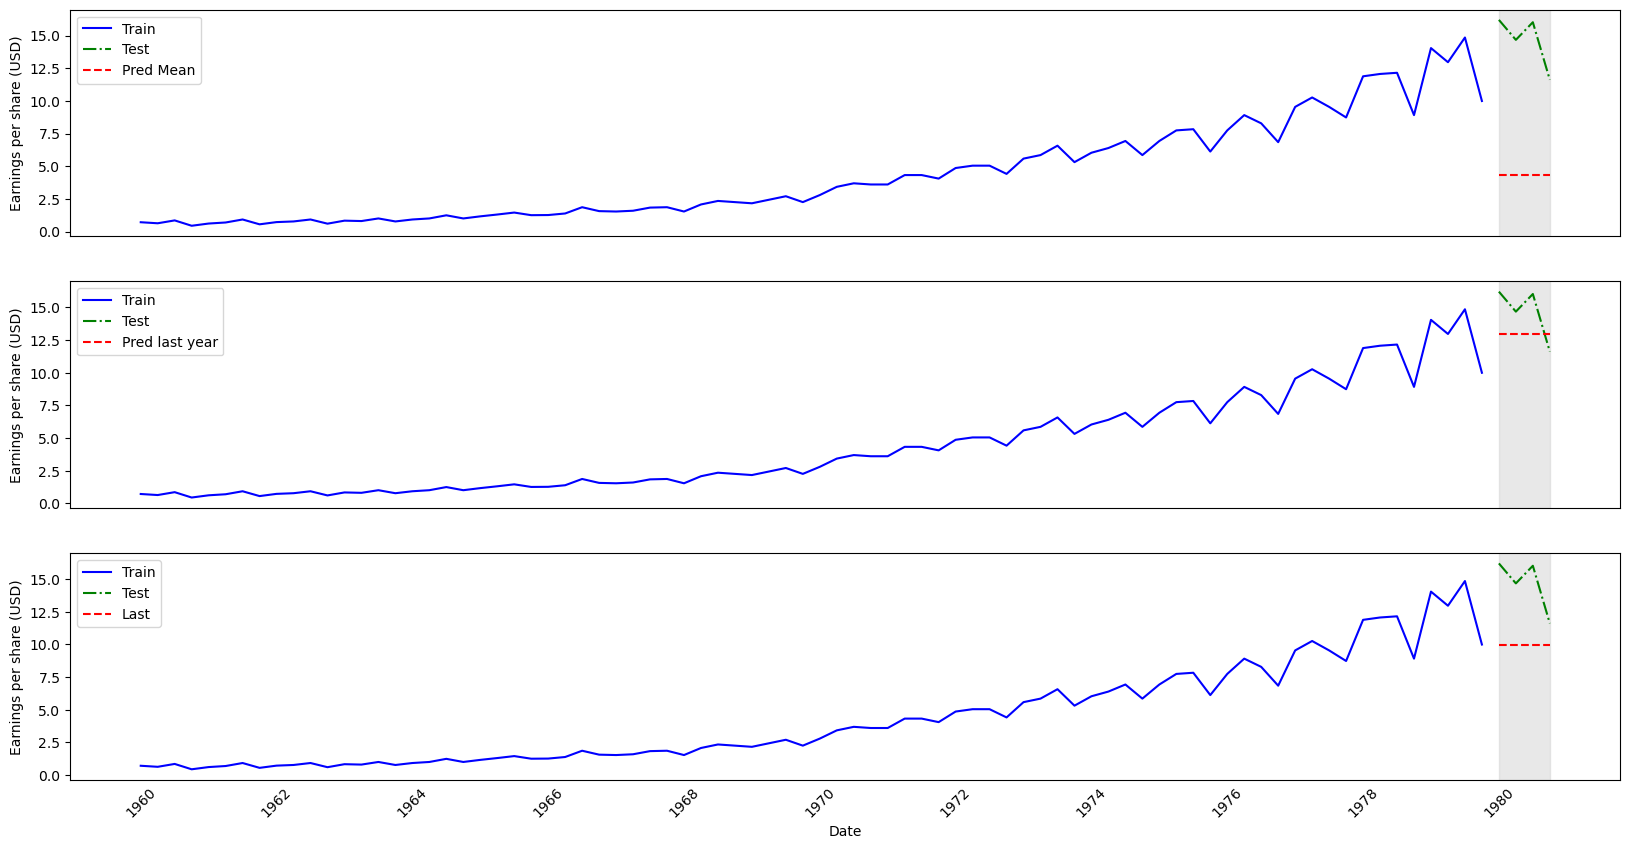

In [24]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(20, 10))
ax[0].plot(train['date'], train['data'], 'b-', label='Train')
ax[0].plot(test['date'], test['data'], 'g-.', label='Test')
ax[0].plot(test['date'], test['pred_mean'], 'r--', label='Pred Mean')
ax[0].set_ylabel('Earnings per share (USD)')
ax[0].axvspan(80, 83, color='lightgray', alpha=0.5)
ax[0].set_xticklabels([])
ax[0].tick_params(axis='x', length=0)
ax[0].legend()


ax[1].plot(train['date'], train['data'], 'b-', label='Train')
ax[1].plot(test['date'], test['data'], 'g-.', label='Test')
ax[1].plot(test['date'], test['pred__last_year_mean'], 'r--', label='Pred last year')
ax[1].set_ylabel('Earnings per share (USD)')
ax[1].axvspan(80, 83, color='lightgray', alpha=0.5)
ax[1].legend()
ax[1].set_xticklabels([])
ax[1].tick_params(axis='x', length=0)


ax[2].plot(train['date'], train['data'], 'b-', label='Train')
ax[2].plot(test['date'], test['data'], 'g-.', label='Test')
ax[2].plot(test['date'], test['pred_last'], 'r--', label='Last')
ax[2].set_xlabel('Date')
ax[2].set_ylabel('Earnings per share (USD)')
ax[2].axvspan(80, 83, color='lightgray', alpha=0.5)
ax[2].legend()
ax[2].set_xticks(np.arange(0, 85, 8))
ax[2].set_xticklabels(np.arange(1960, 1981, 2), rotation=45)
ax[2].tick_params(axis='x', length=0)
plt.show()

# 2.5) Implementing the naive seasonal forecast

In [25]:
test.loc[:, 'pred_last_season'] = train.data.iloc[-4:].values

/tmp/ipykernel_9025/1139299046.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_last_season'] = train.data.iloc[-4:].values


In [26]:
test

,date,data,pred_mean,pred__last_year_mean,pred_last,pred_last_season
80,1980-01-01,16.20,4.3085,12.96,9.99,14.04
81,1980-04-01,14.67,4.3085,12.96,9.99,12.96
82,1980-07-02,16.02,4.3085,12.96,9.99,14.85
83,1980-10-01,11.61,4.3085,12.96,9.99,9.99


In [27]:
mape(test.data, test.pred_last_season)

11.561658552433654

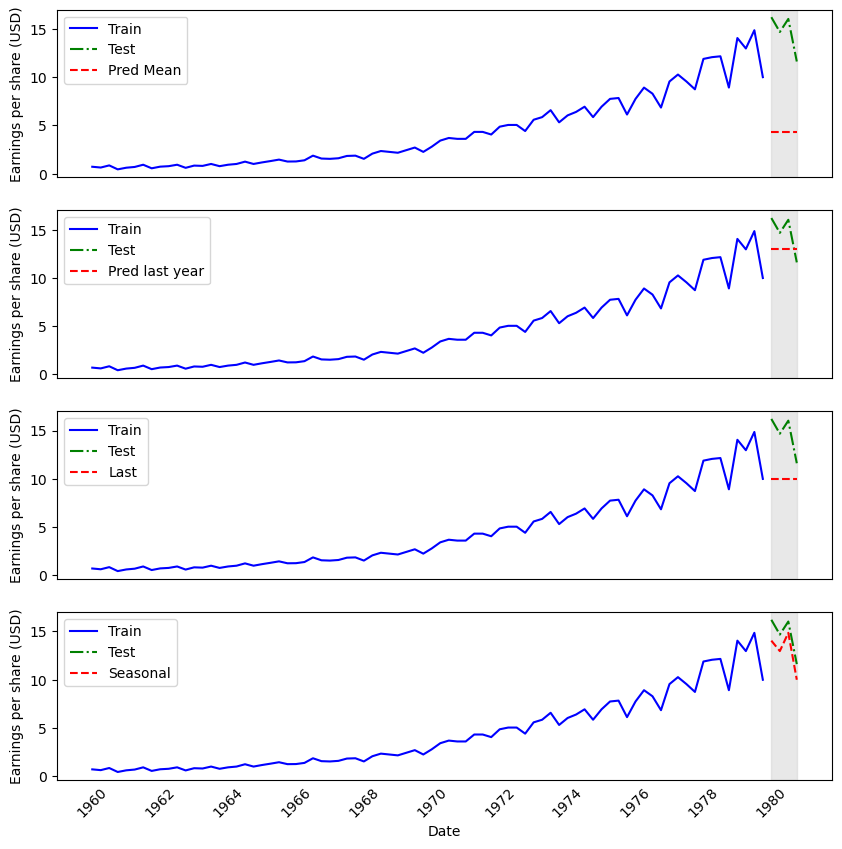

In [28]:
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(10, 10))
ax[0].plot(train['date'], train['data'], 'b-', label='Train')
ax[0].plot(test['date'], test['data'], 'g-.', label='Test')
ax[0].plot(test['date'], test['pred_mean'], 'r--', label='Pred Mean')
ax[0].set_ylabel('Earnings per share (USD)')
ax[0].axvspan(80, 83, color='lightgray', alpha=0.5)
ax[0].set_xticklabels([])
ax[0].tick_params(axis='x', length=0)
ax[0].legend()


ax[1].plot(train['date'], train['data'], 'b-', label='Train')
ax[1].plot(test['date'], test['data'], 'g-.', label='Test')
ax[1].plot(test['date'], test['pred__last_year_mean'], 'r--', label='Pred last year')
ax[1].set_ylabel('Earnings per share (USD)')
ax[1].axvspan(80, 83, color='lightgray', alpha=0.5)
ax[1].legend()
ax[1].set_xticklabels([])
ax[1].tick_params(axis='x', length=0)


ax[2].plot(train['date'], train['data'], 'b-', label='Train')
ax[2].plot(test['date'], test['data'], 'g-.', label='Test')
ax[2].plot(test['date'], test['pred_last'], 'r--', label='Last')
ax[2].set_ylabel('Earnings per share (USD)')
ax[2].axvspan(80, 83, color='lightgray', alpha=0.5)
ax[2].legend(loc='upper left')
ax[2].set_xticklabels([])
ax[2].tick_params(axis='x', length=0)

ax[3].plot(train['date'], train['data'], 'b-', label='Train')
ax[3].plot(test['date'], test['data'], 'g-.', label='Test')
ax[3].plot(test['date'], test['pred_last_season'], 'r--', label='Seasonal')
ax[3].set_xlabel('Date')
ax[3].set_ylabel('Earnings per share (USD)')
ax[3].axvspan(80, 83, color='lightgray', alpha=0.5)
ax[3].legend(loc='upper left')
ax[3].set_xticks(np.arange(0, 85, 8))
ax[3].set_xticklabels(np.arange(1960, 1981, 2), rotation=45)
ax[3].tick_params(axis='x', length=0)
plt.show()